# U-Net Data Preparation

Before training we need two things:
- a fixed train/val/test split (so results are reproducible and comparable across every model we try),
- and a way to turn point annotations into Gaussian heatmap targets.

This notebook creates both and sanity-checks them visually before Week 4/5's actual training notebook builds on top of them.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from bioio import BioImage

from axonbead_ml.data.loading import load_annotations_with_condition, list_all_images_with_condition
from axonbead_ml.data.heatmap import points_to_heatmap
from axonbead_ml.data.splits import make_split, save_split

## Step 1: Create and save the split

70% train / 15% val / 15% test, stratified by condition, fixed seed. This file becomes the
single source of truth for which images are in which split — every future notebook loads it
rather than re-splitting, so train/val/test membership never accidentally changes between runs.

In [3]:
raw_dir = Path("../data/raw")
images = list_all_images_with_condition(raw_dir)

split_df = make_split(images, train_frac=0.7, val_frac=0.15, seed=42)
print(split_df.groupby(["condition", "split"]).size().unstack(fill_value=0))

splits_path = Path("../data/processed/splits.csv")
save_split(split_df, splits_path)
print(f"\nSaved to {splits_path}")

split       test  train  val
condition                   
control        3     14    3
high_beads     3     14    3
low_beads      3     14    3

Saved to ..\data\processed\splits.csv


**Takeaway:** 3 images per condition in val/test is thin, but workable for a first pass and comparing against classical baseline. Data augmentation can be done as a future improvement.

_check the table above — with only 20 images per condition, a 15% val/test split
is just 3 images per condition each. That's thin. Worth deciding now whether that's acceptable
for a portfolio project or whether you'd rather use cross-validation instead — flag this as a
known limitation in the model card either way._

## Step 2: Sanity-check the heatmap conversion

Pick one image, generate its heatmap from the real annotations, and look at it next to the
original — this is the only way to actually judge whether `sigma` (blob size) looks reasonable
before training on it.

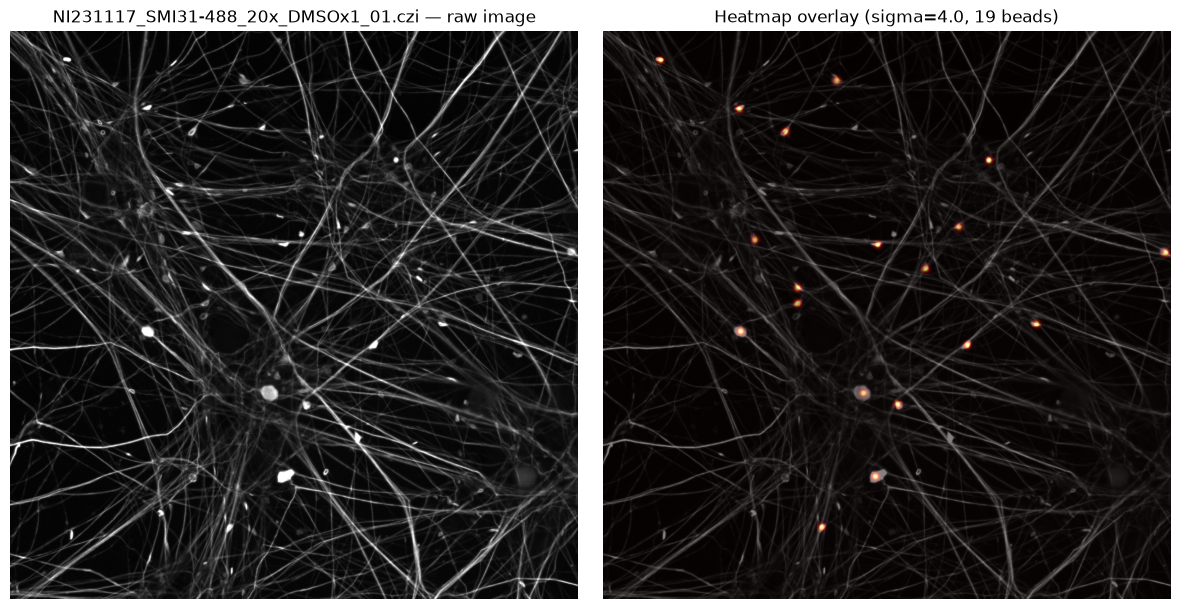

In [10]:
annotations = load_annotations_with_condition(Path("../data/interim/all_annotations.csv"), raw_dir)

example_row = images[images["condition"] == "high_beads"].iloc[0]
img = BioImage(str(example_row["path"]))
image = img.get_image_data("YX", C=1, T=0, Z=0)

points = annotations.loc[annotations["image"] == example_row["image"], ["y", "x"]].values
heatmap = points_to_heatmap(points, image.shape, sigma=4.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"{example_row['image']} — raw image")
axes[0].axis("off")

axes[1].imshow(image, cmap="gray")
axes[1].imshow(heatmap, cmap="hot", alpha=0.5)
axes[1].set_title(f"Heatmap overlay (sigma=4.0, {len(points)} beads)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Takeaway:** the bright blobs in the heatmap line up with the beads in the raw image. Blobs from nearby beads stay separate from eachother and are clearly visible, so sigma value is good.

## Next

With a saved split and a working heatmap function, Steps 4/5's training notebook can now build
the actual U-Net: a PyTorch `Dataset` that loads each image + its heatmap on demand, the model
architecture itself, and a training loop logged to MLflow alongside the classical baseline.